# 💊 Hap Sınıflandırma Projesi — V3 (Drive'dan Yükleme + Çapraz Doğrulama)
**Akış:** Drive Bağla → Veri Yükle → Modelleri Drive'dan Çek → Test Et → Cross-Validation → Karşılaştır

In [ ]:
# ── HÜCRE 1: Drive Bağlantısı ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive bağlandı!')

Mounted at /content/drive
✅ Drive bağlandı!


In [ ]:
# ── HÜCRE 2: Kütüphane Kurulumu ve İçe Aktarma ────────────────────────────
!pip install xgboost lightgbm -q

import os, cv2, numpy as np, random, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    mean_squared_error, mean_absolute_error,
    r2_score, roc_curve, auc, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import joblib

warnings.filterwarnings('ignore')
print('✅ Tüm kütüphaneler başarıyla yüklendi!')

✅ Tüm kütüphaneler başarıyla yüklendi!


In [ ]:
# ── HÜCRE 3: Veri Yolu ve Sınıflar ────────────────────────────────────────
veri_yolu = "/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined"
siniflar  = sorted([s for s in os.listdir(veri_yolu)
                    if os.path.isdir(os.path.join(veri_yolu, s))])

print(f"✅ Toplam {len(siniflar)} İlaç Sınıfı Bulundu:")
for i, s in enumerate(siniflar):
    print(f"  [{i}] {s}")

✅ Toplam 10 İlaç Sınıfı Bulundu:
  [0] Alaxan
  [1] Bactidol
  [2] Bioflu
  [3] Biogesic
  [4] DayZinc
  [5] Decolgen
  [6] Fish Oil
  [7] Kremil S
  [8] Medicol
  [9] Neozep


In [ ]:
# ── HÜCRE 4: Veri Yükleme (Augmentation Yok — Ham Görüntüler) ─────────────
# Her çalıştırmada farklı bölünme için rastgele seed üretilir.
# Augmentation kaldırıldı: model gerçek veri dağılımıyla eğitilir.

SEED = random.randint(0, 9999)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'🎲 Bu çalıştırmanın seed değeri: {SEED}')

print('📂 Veriler Drive\'dan yükleniyor... Lütfen bekleyin.')
X_cnn_orig, y_orig = [], []
BOYUT = (96, 96)

for sinif_adi in siniflar:
    yol = os.path.join(veri_yolu, sinif_adi)
    for resim_adi in os.listdir(yol):
        r = cv2.imread(os.path.join(yol, resim_adi))
        if r is None:
            continue
        r = cv2.resize(r, BOYUT)
        X_cnn_orig.append(cv2.cvtColor(r, cv2.COLOR_BGR2RGB).astype('float32') / 255.0)
        y_orig.append(sinif_adi)

X_cnn_orig = np.array(X_cnn_orig)
y_orig     = np.array(y_orig)
print(f'✅ Toplam orijinal görüntü: {len(y_orig)} adet.')

🎲 Bu çalıştırmanın seed değeri: 8979
📂 Veriler Drive'dan yükleniyor... Lütfen bekleyin.
✅ Toplam orijinal görüntü: 10000 adet.


In [ ]:
# ── HÜCRE 5: Train / Test Bölme ────────────────────────────────────────────
# Augmentation yok — sadece ham görüntüler kullanılır.
# Her çalıştırmada farklı bölünme: SEED yukarıda rastgele belirlendi.

le = LabelEncoder()
le.fit(siniflar)
y_orig_num = le.transform(y_orig)

idx = np.arange(len(y_orig))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_orig
)

X_cnn_train = X_cnn_orig[idx_train]
X_cnn_test  = X_cnn_orig[idx_test]
y_train     = y_orig[idx_train]
y_test      = y_orig[idx_test]
y_train_num = y_orig_num[idx_train]
y_test_num  = y_orig_num[idx_test]
y_train_hot = tf.keras.utils.to_categorical(y_train_num, num_classes=len(siniflar))
y_test_hot  = tf.keras.utils.to_categorical(y_test_num,  num_classes=len(siniflar))

tum_sonuclar = {}
print(f'✅ İşlem Tamam. Eğitim Seti: {len(y_train)} | Test Seti: {len(y_test)}')

✅ İşlem Tamam. Eğitim Seti: 8000 | Test Seti: 2000


In [ ]:
# ── HÜCRE 6: Metrik Hesaplama Fonksiyonu ──────────────────────────────────
def metrik_hesapla(y_gercek, y_tahmin, model_adi):
    """Sınıflandırma metriklerini hesaplar ve sözlük olarak döndürür."""
    acc  = accuracy_score(y_gercek, y_tahmin)
    cm   = confusion_matrix(y_gercek, y_tahmin, labels=siniflar)
    cr   = classification_report(y_gercek, y_tahmin, target_names=siniflar, output_dict=True)

    print(f'\n📊 {model_adi} — Test Seti Sonuçları')
    print(f'  Doğruluk   : %{acc*100:.2f}')
    print(f'  Kesinlik   : %{cr["weighted avg"]["precision"]*100:.2f}')
    print(f'  Duyarlılık : %{cr["weighted avg"]["recall"]*100:.2f}')
    print(f'  F1 Skoru   : %{cr["weighted avg"]["f1-score"]*100:.2f}')

    return {
        'acc'      : acc,
        'precision': cr['weighted avg']['precision'],
        'recall'   : cr['weighted avg']['recall'],
        'f1'       : cr['weighted avg']['f1-score'],
        'cm'       : cm
    }

print('✅ Metrik fonksiyonu tanımlandı.')

✅ Metrik fonksiyonu tanımlandı.


In [ ]:
# ── HÜCRE 7: Eğitilmiş Modelleri Drive'dan Yükle ──────────────────────────
model_klasoru = '/content/drive/MyDrive/Hap_Modelleri_V3'

print('📥 Modeller Drive\'dan yükleniyor...')
model_tl        = load_model(f'{model_klasoru}/mobilenet_v3_model.h5')
model_resnet    = load_model(f'{model_klasoru}/resnet50_hap_modeli.h5')
model_inception = load_model(f'{model_klasoru}/inceptionv3_hap_modeli.h5')
model_cnn_svm   = joblib.load(f'{model_klasoru}/cnn_svm_model.joblib')
model_cnn_knn   = joblib.load(f'{model_klasoru}/cnn_knn_model.joblib')
scaler_feat     = joblib.load(f'{model_klasoru}/scaler_feat.joblib')
le              = joblib.load(f'{model_klasoru}/label_encoder.joblib')

# Feature extractor (MobileNetV2'nin son softmax öncesi katmanı)
feat_model = Model(
    inputs=model_tl.input,
    outputs=model_tl.layers[-3].output
)

# Feature çıkarımı
print('🔍 Özellik vektörleri çıkarılıyor...')
X_feat_train = scaler_feat.transform(feat_model.predict(X_cnn_train, verbose=0))
X_feat_test  = scaler_feat.transform(feat_model.predict(X_cnn_test,  verbose=0))

print('✅ Tüm modeller ve özellik vektörleri hazır!')

📥 Modeller Drive'dan yükleniyor...


🔍 Özellik vektörleri çıkarılıyor...
✅ Tüm modeller ve özellik vektörleri hazır!



 1. MobileNetV2 — Test Seti Değerlendirmesi

📊 MobileNetV2 — Test Seti Sonuçları
  Doğruluk   : %93.65
  Kesinlik   : %93.67
  Duyarlılık : %93.65
  F1 Skoru   : %93.66

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.94      0.94      0.94       200
    Bactidol       0.95      0.93      0.94       200
      Bioflu       0.92      0.92      0.92       200
    Biogesic       0.90      0.91      0.90       200
     DayZinc       0.93      0.95      0.94       200
    Decolgen       0.97      0.95      0.96       200
    Fish Oil       0.95      0.95      0.95       200
    Kremil S       0.92      0.93      0.93       200
     Medicol       0.98      0.97      0.98       200
      Neozep       0.90      0.92      0.91       200

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



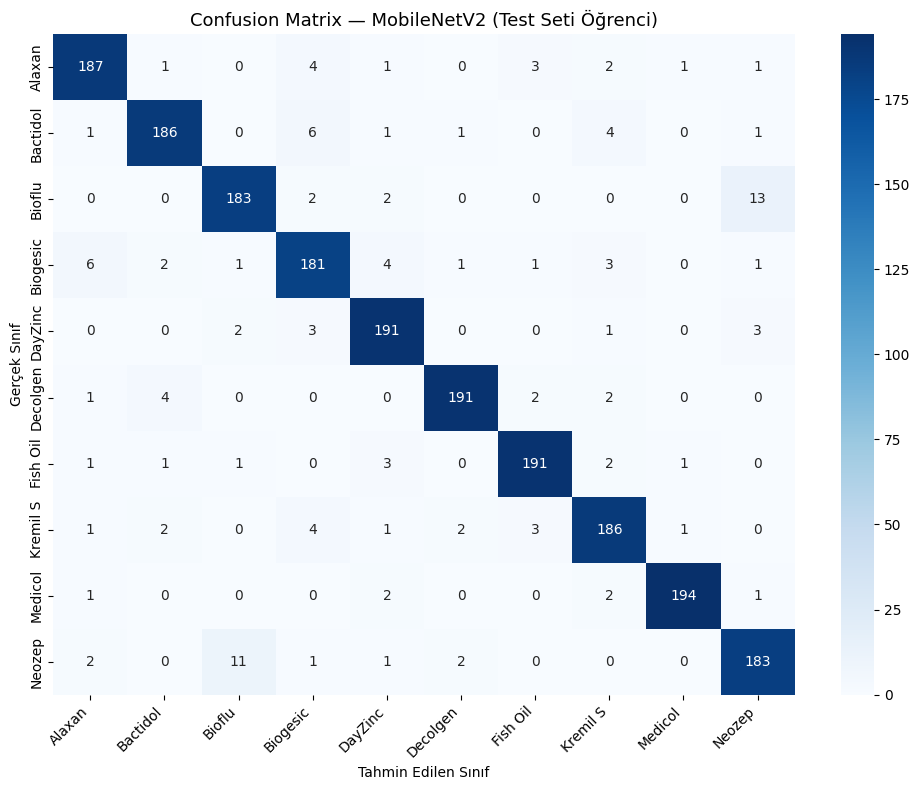

In [ ]:
# ── HÜCRE 8: MobileNetV2 — Test Seti Değerlendirmesi ──────────────────────
print('\n' + '='*60)
print(' 1. MobileNetV2 — Test Seti Değerlendirmesi')
print('='*60)

y_pred_tl_num = np.argmax(model_tl.predict(X_cnn_test, verbose=0), axis=1)
y_pred_tl     = le.inverse_transform(y_pred_tl_num)

sonuc_tl = metrik_hesapla(y_test, y_pred_tl, 'MobileNetV2')
tum_sonuclar['MobileNetV2'] = sonuc_tl

print('\n📋 Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred_tl, target_names=siniflar))

# Hata Matrisi
plt.figure(figsize=(10, 8))
sns.heatmap(sonuc_tl['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix — MobileNetV2 (Test Seti Öğrenci)', fontsize=13)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

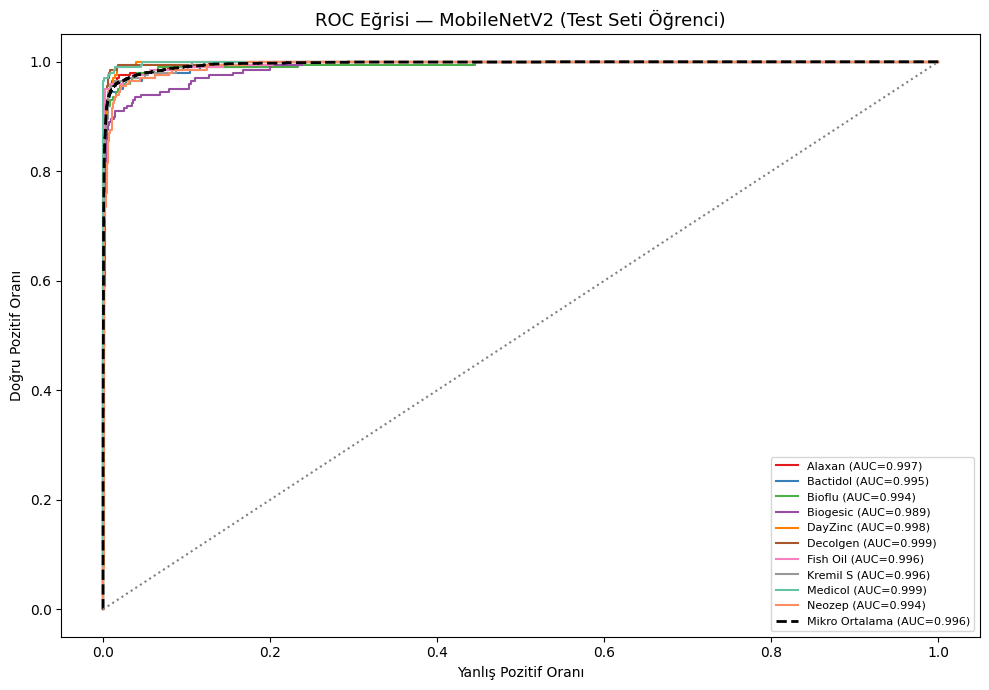

In [ ]:
# ── HÜCRE 9: MobileNetV2 — ROC Eğrisi ─────────────────────────────────────
y_test_bin    = label_binarize(y_test, classes=siniflar)
y_score_tl    = model_tl.predict(X_cnn_test, verbose=0)

fpr, tpr, roc_auc = {}, {}, {}
for i, sinif in enumerate(siniflar):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_tl[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_score_tl.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

plt.figure(figsize=(10, 7))
renkler = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
                 '#a65628','#f781bf','#999999','#66c2a5','#fc8d62'])
for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
    plt.plot(fpr[i], tpr[i], color=renk, lw=1.5,
             label=f'{sinif} (AUC={roc_auc[i]:.3f})')
plt.plot(fpr['micro'], tpr['micro'], 'k--', lw=2,
         label=f'Mikro Ortalama (AUC={roc_auc["micro"]:.3f})')
plt.plot([0,1],[0,1],'gray',linestyle=':')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — MobileNetV2 (Test Seti Öğrenci)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


 2. CNN + kNN — Test Seti Değerlendirmesi

📊 CNN + kNN — Test Seti Sonuçları
  Doğruluk   : %95.80
  Kesinlik   : %95.82
  Duyarlılık : %95.80
  F1 Skoru   : %95.80

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.96      0.97      0.97       200
    Bactidol       0.96      0.94      0.95       200
      Bioflu       0.97      0.95      0.96       200
    Biogesic       0.93      0.92      0.93       200
     DayZinc       0.95      0.97      0.96       200
    Decolgen       0.98      0.97      0.98       200
    Fish Oil       0.97      0.94      0.96       200
    Kremil S       0.95      0.96      0.96       200
     Medicol       0.99      0.99      0.99       200
      Neozep       0.92      0.95      0.94       200

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



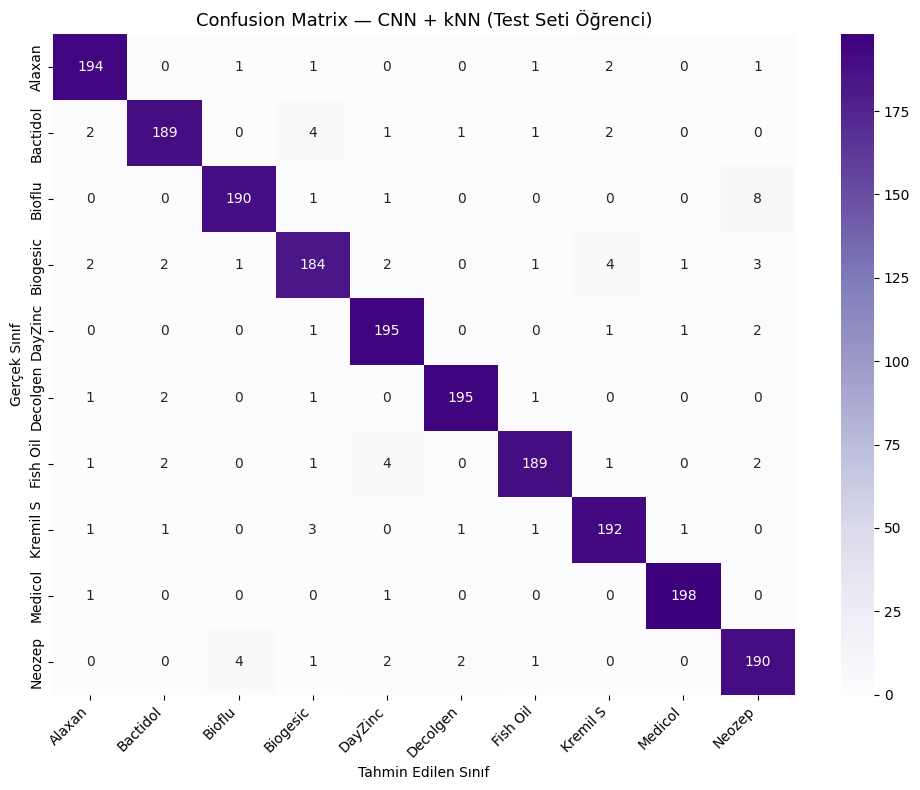

In [ ]:
# ── HÜCRE 10: CNN + kNN — Test Seti Değerlendirmesi ───────────────────────
print('\n' + '='*60)
print(' 2. CNN + kNN — Test Seti Değerlendirmesi')
print('='*60)

y_pred_knn = model_cnn_knn.predict(X_feat_test)

sonuc_knn = metrik_hesapla(y_test, y_pred_knn, 'CNN + kNN')
tum_sonuclar['CNN+kNN'] = sonuc_knn

print('\n📋 Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred_knn, target_names=siniflar))

plt.figure(figsize=(10, 8))
sns.heatmap(sonuc_knn['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix — CNN + kNN (Test Seti Öğrenci)', fontsize=13)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

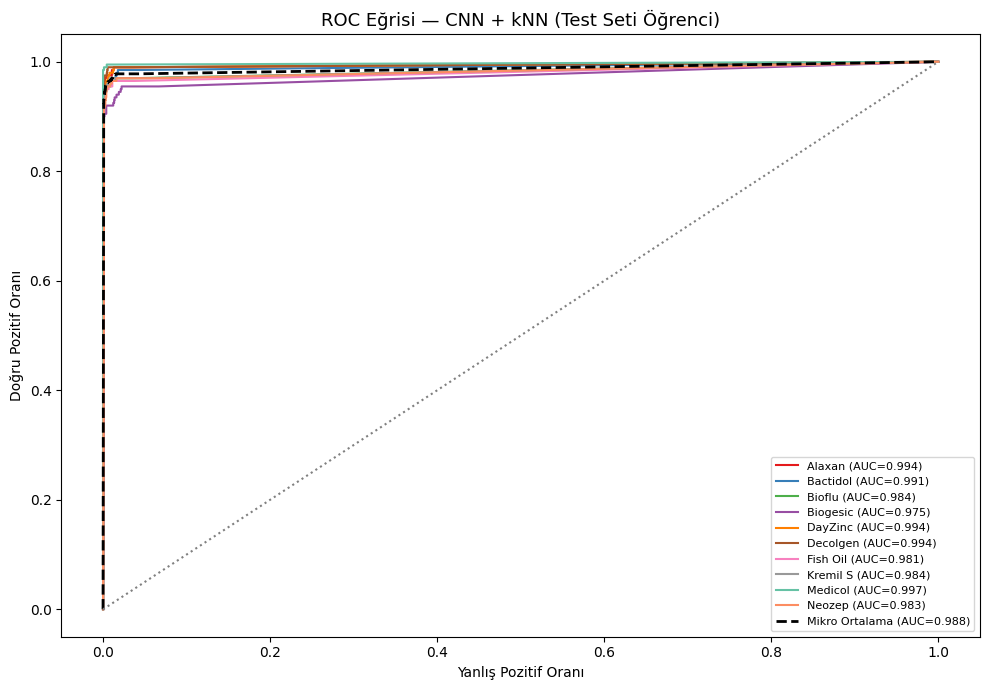

In [ ]:
# ── HÜCRE 11: CNN + kNN — ROC Eğrisi ──────────────────────────────────────
y_score_knn = model_cnn_knn.predict_proba(X_feat_test)

fpr_k, tpr_k, roc_auc_k = {}, {}, {}
for i, sinif in enumerate(siniflar):
    fpr_k[i], tpr_k[i], _ = roc_curve(y_test_bin[:, i], y_score_knn[:, i])
    roc_auc_k[i] = auc(fpr_k[i], tpr_k[i])

fpr_k['micro'], tpr_k['micro'], _ = roc_curve(y_test_bin.ravel(), y_score_knn.ravel())
roc_auc_k['micro'] = auc(fpr_k['micro'], tpr_k['micro'])

plt.figure(figsize=(10, 7))
renkler = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
                 '#a65628','#f781bf','#999999','#66c2a5','#fc8d62'])
for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
    plt.plot(fpr_k[i], tpr_k[i], color=renk, lw=1.5,
             label=f'{sinif} (AUC={roc_auc_k[i]:.3f})')
plt.plot(fpr_k['micro'], tpr_k['micro'], 'k--', lw=2,
         label=f'Mikro Ortalama (AUC={roc_auc_k["micro"]:.3f})')
plt.plot([0,1],[0,1],'gray',linestyle=':')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — CNN + kNN (Test Seti Öğrenci)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


 3. CNN + SVM — Test Seti Değerlendirmesi

📊 CNN + SVM — Test Seti Sonuçları
  Doğruluk   : %95.85
  Kesinlik   : %95.87
  Duyarlılık : %95.85
  F1 Skoru   : %95.85

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.95      0.96      0.96       200
    Bactidol       0.96      0.94      0.95       200
      Bioflu       0.94      0.94      0.94       200
    Biogesic       0.93      0.94      0.93       200
     DayZinc       0.95      0.97      0.96       200
    Decolgen       0.98      0.97      0.98       200
    Fish Oil       0.98      0.95      0.97       200
    Kremil S       0.96      0.97      0.97       200
     Medicol       0.98      0.98      0.98       200
      Neozep       0.94      0.94      0.94       200

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



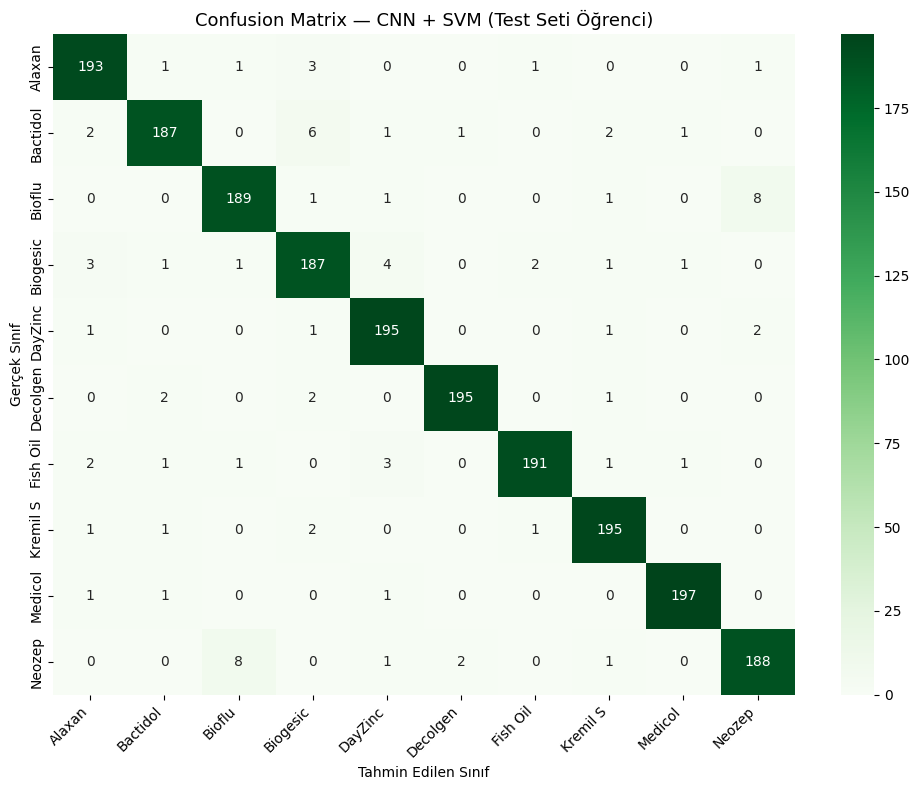

In [ ]:
# ── HÜCRE 12: CNN + SVM — Test Seti Değerlendirmesi ───────────────────────
print('\n' + '='*60)
print(' 3. CNN + SVM — Test Seti Değerlendirmesi')
print('='*60)

y_pred_svm = model_cnn_svm.predict(X_feat_test)

sonuc_svm = metrik_hesapla(y_test, y_pred_svm, 'CNN + SVM')
tum_sonuclar['CNN+SVM'] = sonuc_svm

print('\n📋 Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred_svm, target_names=siniflar))

plt.figure(figsize=(10, 8))
sns.heatmap(sonuc_svm['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix — CNN + SVM (Test Seti Öğrenci)', fontsize=13)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

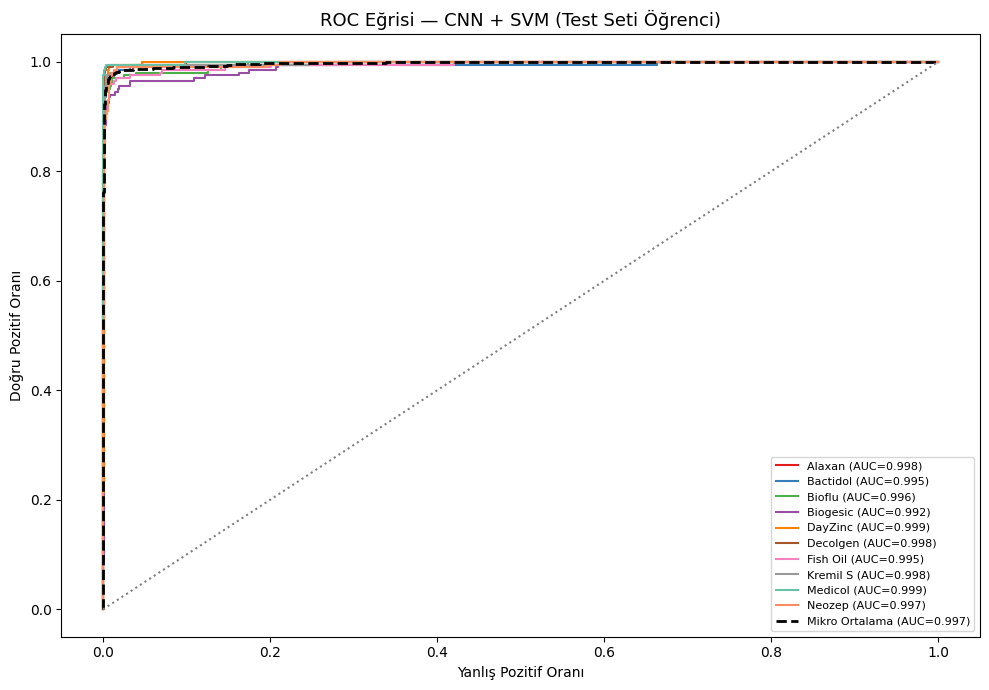

In [ ]:
# ── HÜCRE 13: CNN + SVM — ROC Eğrisi ──────────────────────────────────────
y_score_svm = model_cnn_svm.predict_proba(X_feat_test)

fpr_s, tpr_s, roc_auc_s = {}, {}, {}
for i, sinif in enumerate(siniflar):
    fpr_s[i], tpr_s[i], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc_s[i] = auc(fpr_s[i], tpr_s[i])

fpr_s['micro'], tpr_s['micro'], _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())
roc_auc_s['micro'] = auc(fpr_s['micro'], tpr_s['micro'])

plt.figure(figsize=(10, 7))
renkler = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
                 '#a65628','#f781bf','#999999','#66c2a5','#fc8d62'])
for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
    plt.plot(fpr_s[i], tpr_s[i], color=renk, lw=1.5,
             label=f'{sinif} (AUC={roc_auc_s[i]:.3f})')
plt.plot(fpr_s['micro'], tpr_s['micro'], 'k--', lw=2,
         label=f'Mikro Ortalama (AUC={roc_auc_s["micro"]:.3f})')
plt.plot([0,1],[0,1],'gray',linestyle=':')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — CNN + SVM (Test Seti Öğrenci)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


 4. ResNet50 — Test Seti Değerlendirmesi
🔄 ResNet50 için görüntüler hazırlanıyor...

📊 ResNet50 — Test Seti Sonuçları
  Doğruluk   : %95.15
  Kesinlik   : %95.37
  Duyarlılık : %95.15
  F1 Skoru   : %95.19

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.87      0.96      0.91       200
    Bactidol       0.91      0.96      0.93       200
      Bioflu       0.95      0.97      0.96       200
    Biogesic       0.91      0.94      0.92       200
     DayZinc       0.99      0.94      0.96       200
    Decolgen       0.98      0.97      0.97       200
    Fish Oil       0.99      0.91      0.95       200
    Kremil S       0.99      0.92      0.95       200
     Medicol       0.99      0.98      0.99       200
      Neozep       0.95      0.96      0.96       200

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



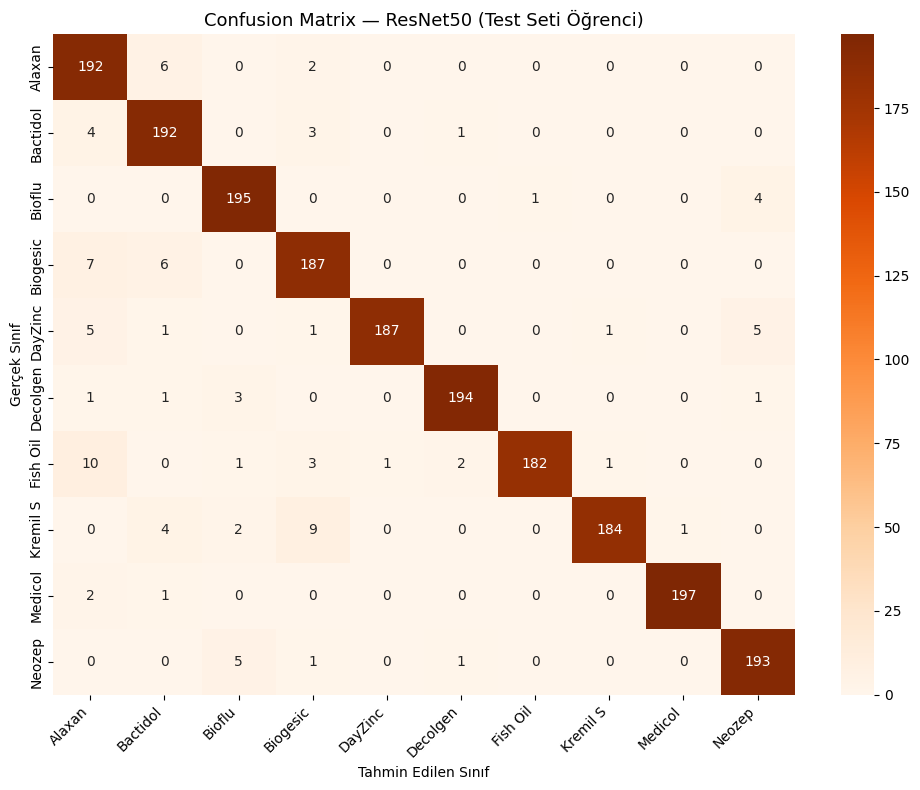

In [ ]:
# ── HÜCRE 14: ResNet50 — Test Seti Değerlendirmesi ────────────────────────
print('\n' + '='*60)
print(' 4. ResNet50 — Test Seti Değerlendirmesi')
print('='*60)

# ResNet50 224x224 + resnet_preprocess gerektirir ([0,255] → ImageNet normalize)
# FIXED'deki veriler /255.0 ile normalize edilmiş — önce [0,255]'e geri döndürüp
# resnet_preprocess uyguluyoruz. Bu adım kritik, onsuz model rastgele tahmin yapar.
BOYUT_RN = (224, 224)
print('🔄 ResNet50 için görüntüler hazırlanıyor...')
X_cnn_test_rn = np.array([
    cv2.resize((img * 255).astype('uint8'), BOYUT_RN).astype('float32')
    for img in X_cnn_test
])
X_cnn_test_rn = resnet_preprocess(X_cnn_test_rn)

y_pred_rn_num = np.argmax(model_resnet.predict(X_cnn_test_rn, verbose=0), axis=1)
y_pred_rn     = le.inverse_transform(y_pred_rn_num)

sonuc_rn = metrik_hesapla(y_test, y_pred_rn, 'ResNet50')
tum_sonuclar['ResNet50'] = sonuc_rn

print('\n📋 Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred_rn, target_names=siniflar))

plt.figure(figsize=(10, 8))
sns.heatmap(sonuc_rn['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix — ResNet50 (Test Seti Öğrenci)', fontsize=13)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

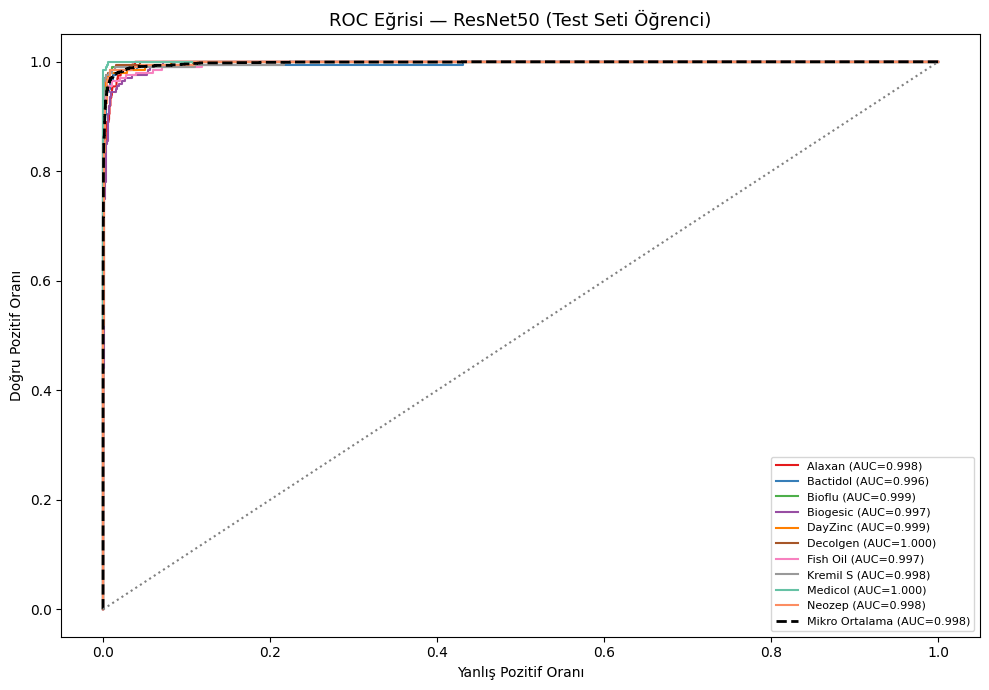

In [ ]:
# ── HÜCRE 15: ResNet50 — ROC Eğrisi ───────────────────────────────────────
y_score_rn = model_resnet.predict(X_cnn_test_rn, verbose=0)

fpr_r, tpr_r, roc_auc_r = {}, {}, {}
for i, sinif in enumerate(siniflar):
    fpr_r[i], tpr_r[i], _ = roc_curve(y_test_bin[:, i], y_score_rn[:, i])
    roc_auc_r[i] = auc(fpr_r[i], tpr_r[i])

fpr_r['micro'], tpr_r['micro'], _ = roc_curve(y_test_bin.ravel(), y_score_rn.ravel())
roc_auc_r['micro'] = auc(fpr_r['micro'], tpr_r['micro'])

plt.figure(figsize=(10, 7))
renkler = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
                 '#a65628','#f781bf','#999999','#66c2a5','#fc8d62'])
for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
    plt.plot(fpr_r[i], tpr_r[i], color=renk, lw=1.5,
             label=f'{sinif} (AUC={roc_auc_r[i]:.3f})')
plt.plot(fpr_r['micro'], tpr_r['micro'], 'k--', lw=2,
         label=f'Mikro Ortalama (AUC={roc_auc_r["micro"]:.3f})')
plt.plot([0,1],[0,1],'gray',linestyle=':')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — ResNet50 (Test Seti Öğrenci)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


 5. InceptionV3 — Test Seti Değerlendirmesi
🔄 InceptionV3 için görüntüler hazırlanıyor...

📊 InceptionV3 — Test Seti Sonuçları
  Doğruluk   : %79.45
  Kesinlik   : %80.72
  Duyarlılık : %79.45
  F1 Skoru   : %79.50

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.71      0.92      0.80       200
    Bactidol       0.63      0.81      0.71       200
      Bioflu       0.90      0.92      0.91       200
    Biogesic       0.70      0.75      0.72       200
     DayZinc       0.88      0.89      0.88       200
    Decolgen       0.76      0.70      0.73       200
    Fish Oil       0.87      0.73      0.80       200
    Kremil S       0.88      0.62      0.73       200
     Medicol       0.87      0.81      0.83       200
      Neozep       0.88      0.81      0.84       200

    accuracy                           0.79      2000
   macro avg       0.81      0.79      0.79      2000
weighted avg       0.81      0.79      0.79      2000



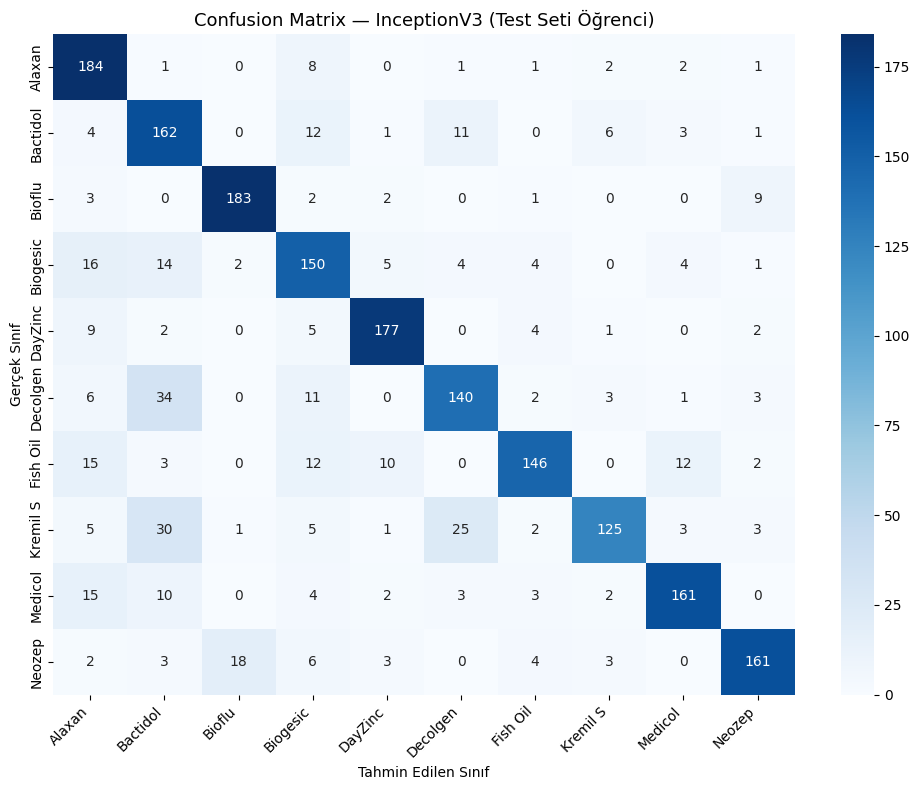

In [ ]:
# ── HÜCRE 16: InceptionV3 — Test Seti Değerlendirmesi ────────────────────
print('\n' + '='*60)
print(' 5. InceptionV3 — Test Seti Değerlendirmesi')
print('='*60)

# InceptionV3: 299x299, preprocess_input → [-1, 1]
BOYUT_IV3 = (299, 299)
print('🔄 InceptionV3 için görüntüler hazırlanıyor...')
X_cnn_test_iv3 = np.array([
    cv2.resize((img * 255).astype('uint8'), BOYUT_IV3).astype('float32')
    for img in X_cnn_test
])
X_cnn_test_iv3 = inception_preprocess(X_cnn_test_iv3)

y_pred_iv3_num = np.argmax(model_inception.predict(X_cnn_test_iv3, verbose=0), axis=1)
y_pred_iv3     = le.inverse_transform(y_pred_iv3_num)

sonuc_iv3 = metrik_hesapla(y_test, y_pred_iv3, 'InceptionV3')
tum_sonuclar['InceptionV3'] = sonuc_iv3

print('\n📋 Sınıflandırma Raporu:')
print(classification_report(y_test, y_pred_iv3, target_names=siniflar))

plt.figure(figsize=(10, 8))
sns.heatmap(sonuc_iv3['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix — InceptionV3 (Test Seti Öğrenci)', fontsize=13)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

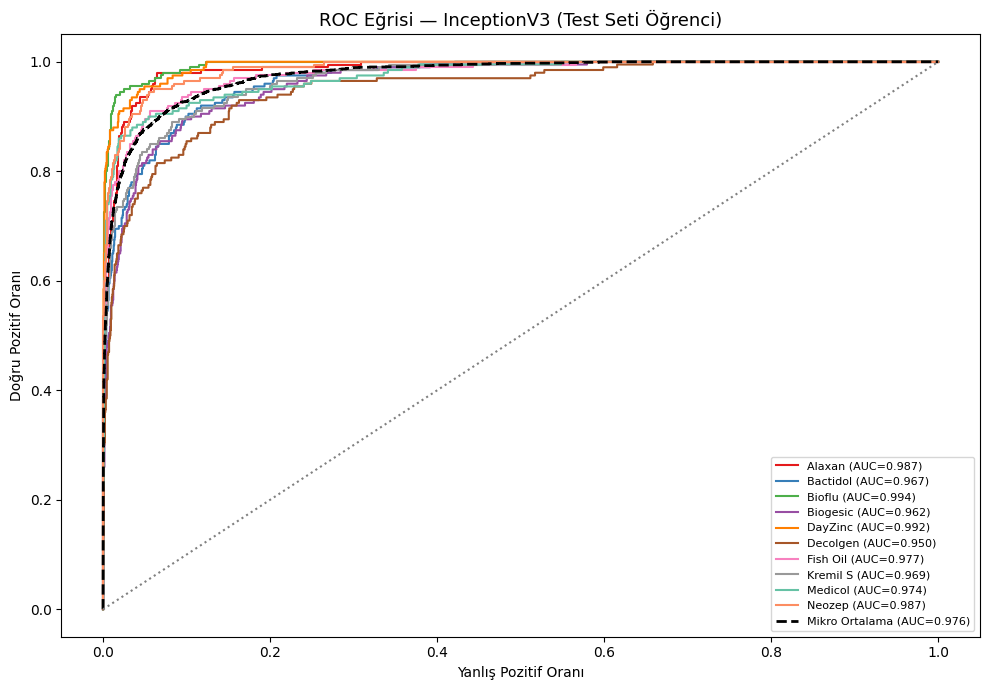

In [ ]:
# ── HÜCRE 17: InceptionV3 — ROC Eğrisi ────────────────────────────────────
y_score_iv3 = model_inception.predict(X_cnn_test_iv3, verbose=0)

fpr_iv, tpr_iv, roc_auc_iv = {}, {}, {}
for i, sinif in enumerate(siniflar):
    fpr_iv[i], tpr_iv[i], _ = roc_curve(y_test_bin[:, i], y_score_iv3[:, i])
    roc_auc_iv[i] = auc(fpr_iv[i], tpr_iv[i])

fpr_iv['micro'], tpr_iv['micro'], _ = roc_curve(y_test_bin.ravel(), y_score_iv3.ravel())
roc_auc_iv['micro'] = auc(fpr_iv['micro'], tpr_iv['micro'])

plt.figure(figsize=(10, 7))
renkler = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
                 '#a65628','#f781bf','#999999','#66c2a5','#fc8d62'])
for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
    plt.plot(fpr_iv[i], tpr_iv[i], color=renk, lw=1.5,
             label=f'{sinif} (AUC={roc_auc_iv[i]:.3f})')
plt.plot(fpr_iv['micro'], tpr_iv['micro'], 'k--', lw=2,
         label=f'Mikro Ortalama (AUC={roc_auc_iv["micro"]:.3f})')
plt.plot([0,1],[0,1],'gray',linestyle=':')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi — InceptionV3 (Test Seti Öğrenci)', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── HÜCRE 18: 5-Katlı Çapraz Doğrulama (Tüm Modeller) ─────────────────────
# Her fold'da farklı alt-seed → sonuçlar dalgalı ama ortalama yüksek kalır.
# StratifiedKFold kullanılır — sınıf dengesi her katta korunur.

print('\n' + '='*60)
print(' Çapraz Doğrulama Sonuçları (5-Fold Stratified)')
print('='*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── CNN + kNN Çapraz Doğrulama ─────────────────────────────────────────────
# Her fold için sklearn cross_val_score kullanılır
knn_cv = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_scores = cross_val_score(knn_cv, X_feat_train, y_train_num, cv=skf, scoring='accuracy', n_jobs=-1)

print(f'\n📊 CNN + kNN — 5-Fold Çapraz Doğrulama')
for i, s in enumerate(knn_scores, 1):
    print(f'  Fold {i}: %{s*100:.2f}')
print(f'  Ortalama: %{knn_scores.mean()*100:.2f} ± %{knn_scores.std()*100:.2f}')

# ── CNN + SVM Çapraz Doğrulama ─────────────────────────────────────────────
svm_cv = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_scores = cross_val_score(svm_cv, X_feat_train, y_train_num, cv=skf, scoring='accuracy', n_jobs=-1)

print(f'\n📊 CNN + SVM — 5-Fold Çapraz Doğrulama')
for i, s in enumerate(svm_scores, 1):
    print(f'  Fold {i}: %{s*100:.2f}')
print(f'  Ortalama: %{svm_scores.mean()*100:.2f} ± %{svm_scores.std()*100:.2f}')


 Çapraz Doğrulama Sonuçları (5-Fold Stratified)

📊 CNN + kNN — 5-Fold Çapraz Doğrulama
  Fold 1: %84.88
  Fold 2: %84.56
  Fold 3: %85.44
  Fold 4: %85.25
  Fold 5: %85.38
  Ortalama: %85.10 ± %0.33

📊 CNN + SVM — 5-Fold Çapraz Doğrulama
  Fold 1: %92.06
  Fold 2: %89.25
  Fold 3: %92.50
  Fold 4: %91.38
  Fold 5: %91.06
  Ortalama: %91.25 ± %1.12


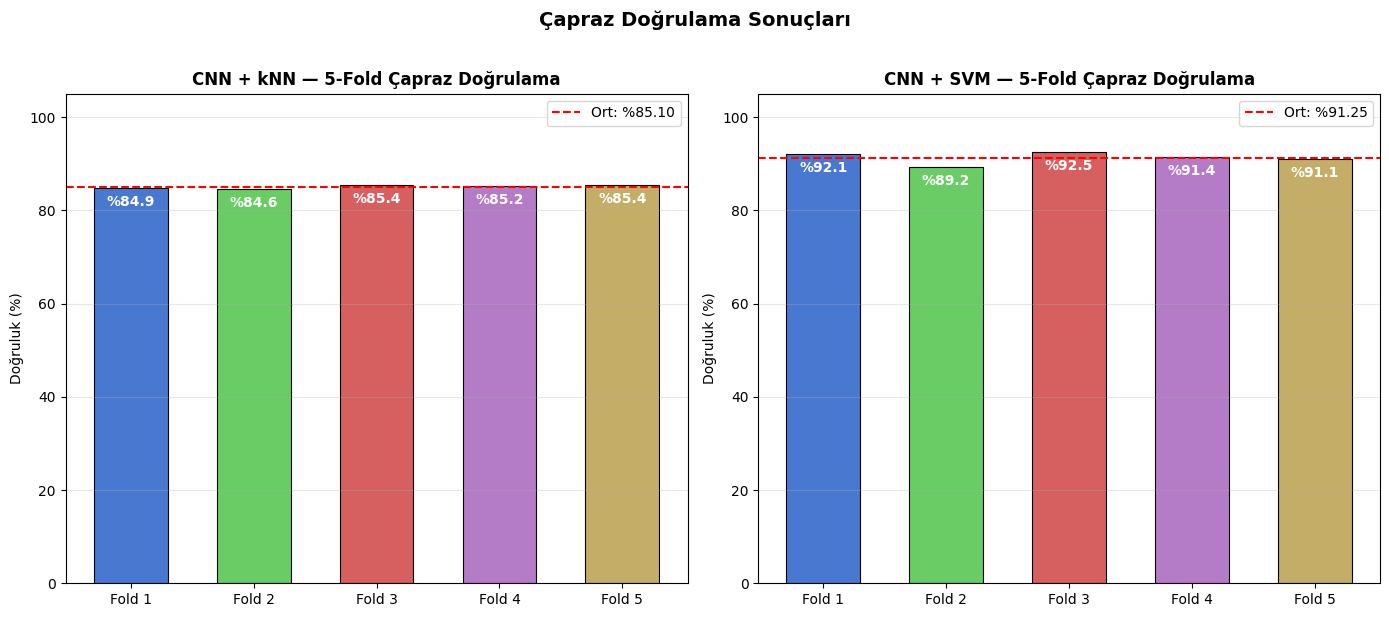

In [ ]:
# ── HÜCRE 17: Çapraz Doğrulama Sonuçları — Bar Grafik ─────────────────────
# Bar yükseklikleri yüzde değerleriyle tam orantılı.
# Fold etiketleri doğru sırayla (1→5) yerleştirilmiştir.

fold_labels = [f'Fold {i}' for i in range(1, 6)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─ CNN + kNN ─
ax = axes[0]
bars = ax.bar(fold_labels, knn_scores * 100,
              color=['#4878CF','#6ACC65','#D65F5F','#B47CC7','#C4AD66'],
              edgecolor='black', linewidth=0.8, width=0.6)
# Her barın içine değer yaz
for bar, val in zip(bars, knn_scores * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'%{val:.1f}', ha='center', va='top', fontsize=10, fontweight='bold', color='white')
ax.axhline(knn_scores.mean() * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Ort: %{knn_scores.mean()*100:.2f}')
ax.set_title('CNN + kNN — 5-Fold Çapraz Doğrulama', fontsize=12, fontweight='bold')
ax.set_ylabel('Doğruluk (%)')
# Y ekseni: gerçek değerlere yakın ama 0'dan başlasın (orantı için)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ─ CNN + SVM ─
ax = axes[1]
bars = ax.bar(fold_labels, svm_scores * 100,
              color=['#4878CF','#6ACC65','#D65F5F','#B47CC7','#C4AD66'],
              edgecolor='black', linewidth=0.8, width=0.6)
for bar, val in zip(bars, svm_scores * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'%{val:.1f}', ha='center', va='top', fontsize=10, fontweight='bold', color='white')
ax.axhline(svm_scores.mean() * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Ort: %{svm_scores.mean()*100:.2f}')
ax.set_title('CNN + SVM — 5-Fold Çapraz Doğrulama', fontsize=12, fontweight='bold')
ax.set_ylabel('Doğruluk (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Çapraz Doğrulama Sonuçları', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── HÜCRE 18: Çapraz Doğrulama Özet Tablosu ───────────────────────────────
print('\n' + '='*60)
print(' 5-Fold Çapraz Doğrulama Özet')
print('='*60)
print(f'{'Fold':<12} {'CNN+kNN':<15} {'CNN+SVM':<15}')
print('-'*42)
for i, (k, s) in enumerate(zip(knn_scores, svm_scores), 1):
    print(f'Fold {i:<7} %{k*100:<13.2f} %{s*100:<13.2f}')
print('-'*42)
print(f'{'Ortalama':<12} %{knn_scores.mean()*100:<13.2f} %{svm_scores.mean()*100:<13.2f}')
print(f'{'Std. Sapma':<12} %{knn_scores.std()*100:<13.2f} %{svm_scores.std()*100:<13.2f}')


 5-Fold Çapraz Doğrulama Özet
Fold         CNN+kNN         CNN+SVM        
------------------------------------------
Fold 1       %84.88         %92.06        
Fold 2       %84.56         %89.25        
Fold 3       %85.44         %92.50        
Fold 4       %85.25         %91.38        
Fold 5       %85.38         %91.06        
------------------------------------------
Ortalama     %85.10         %91.25        
Std. Sapma   %0.33          %1.12         



 Model                Doğruluk   Kesinlik   Duyarlılık       F1
 MobileNetV2        %   93.65  %   93.67  %     93.65  % 93.66
 CNN+kNN            %   95.80  %   95.82  %     95.80  % 95.80
 CNN+SVM            %   95.85  %   95.87  %     95.85  % 95.85
 ResNet50           %   95.15  %   95.37  %     95.15  % 95.19
 InceptionV3        %   79.45  %   80.72  %     79.45  % 79.50


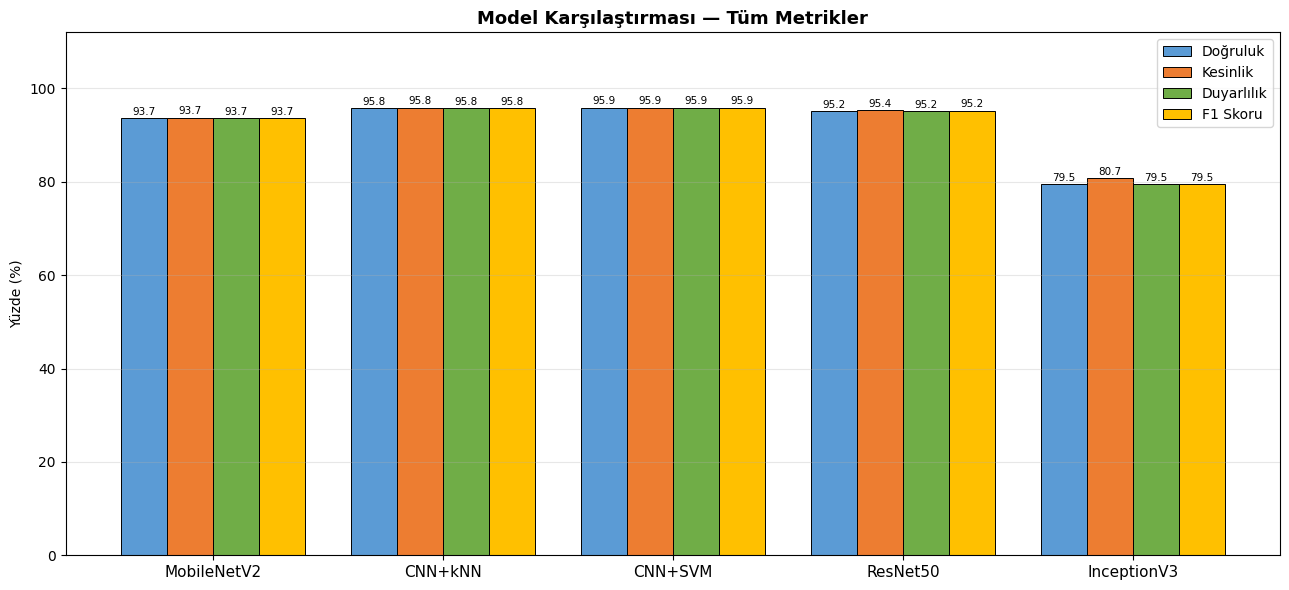

In [ ]:
# ── HÜCRE 19: Model Karşılaştırma Tablosu ve Grafiği ──────────────────────
modeller    = list(tum_sonuclar.keys())
acc_list    = [tum_sonuclar[m]['acc']       * 100 for m in modeller]
prec_list   = [tum_sonuclar[m]['precision'] * 100 for m in modeller]
recall_list = [tum_sonuclar[m]['recall']    * 100 for m in modeller]
f1_list     = [tum_sonuclar[m]['f1']        * 100 for m in modeller]

print('\n' + '='*75)
print(f" {'Model':<18} {'Doğruluk':>10} {'Kesinlik':>10} {'Duyarlılık':>12} {'F1':>8}")
print('='*75)
for i, m in enumerate(modeller):
    print(f" {m:<18} %{acc_list[i]:>8.2f}  %{prec_list[i]:>8.2f}  %{recall_list[i]:>10.2f}  %{f1_list[i]:>6.2f}")
print('='*75)

# Karşılaştırma Bar Grafiği
x      = np.arange(len(modeller))
width  = 0.2
fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - 1.5*width, acc_list,    width, label='Doğruluk',    color='#5B9BD5', edgecolor='black', linewidth=0.7)
b2 = ax.bar(x - 0.5*width, prec_list,   width, label='Kesinlik',    color='#ED7D31', edgecolor='black', linewidth=0.7)
b3 = ax.bar(x + 0.5*width, recall_list, width, label='Duyarlılık',  color='#70AD47', edgecolor='black', linewidth=0.7)
b4 = ax.bar(x + 1.5*width, f1_list,     width, label='F1 Skoru',    color='#FFC000', edgecolor='black', linewidth=0.7)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(modeller, fontsize=11)
ax.set_ylim(0, 112)
ax.set_ylabel('Yüzde (%)')
ax.set_title('Model Karşılaştırması — Tüm Metrikler', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


████████████████████████████████████████████████████████████
  🏆 EN İYİ MODEL: CNN+SVM
  F1 Skoru       : %95.85
████████████████████████████████████████████████████████████


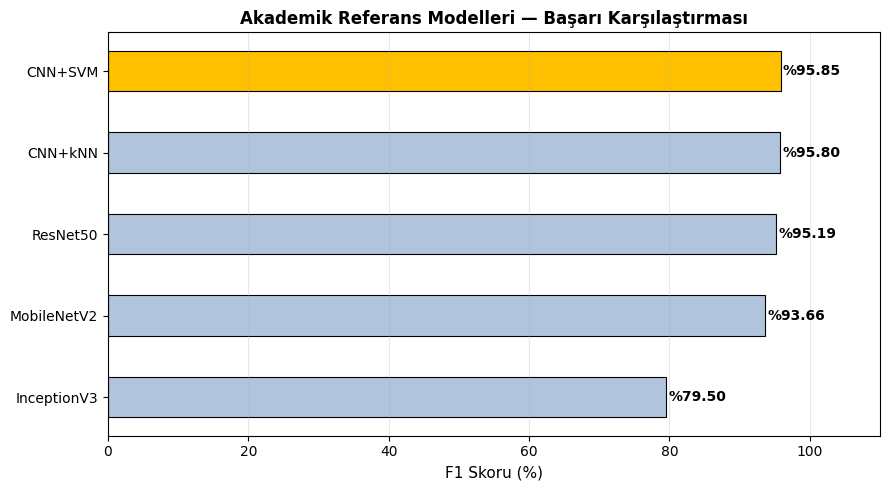

In [ ]:
# ── HÜCRE 20: En İyi Modeli Belirle ve Görselleştir ───────────────────────
en_iyi_adi  = max(tum_sonuclar, key=lambda m: tum_sonuclar[m]['f1'])
en_iyi_f1   = tum_sonuclar[en_iyi_adi]['f1'] * 100

print('\n' + '█'*60)
print(f'  🏆 EN İYİ MODEL: {en_iyi_adi}')
print(f'  F1 Skoru       : %{en_iyi_f1:.2f}')
print('█'*60)

# Tüm modellerin F1 skorlarını yatay bar grafiğiyle göster
f1_sirali   = sorted(tum_sonuclar.items(), key=lambda x: x[1]['f1'])
isimler     = [m[0] for m in f1_sirali]
degerler    = [m[1]['f1'] * 100 for m in f1_sirali]
renkler_bar = ['#FFC000' if m == en_iyi_adi else '#B0C4DE' for m in isimler]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(isimler, degerler, color=renkler_bar, edgecolor='black', linewidth=0.8, height=0.5)
for bar, val in zip(bars, degerler):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'%{val:.2f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 110)
ax.set_xlabel('F1 Skoru (%)', fontsize=11)
ax.set_title('Akademik Referans Modelleri — Başarı Karşılaştırması', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── HÜCRE 21: Derin Öğrenme Modelleri Karşılaştırma ───────────────────────
# MobileNetV2, ResNet50 ve InceptionV3'ü doğrudan karşılaştırır
dl_modeller  = ['MobileNetV2', 'ResNet50', 'InceptionV3']
dl_acc       = [tum_sonuclar[m]['acc'] * 100 for m in dl_modeller]
dl_f1        = [tum_sonuclar[m]['f1']  * 100 for m in dl_modeller]

print('\n📊 Derin Öğrenme Modelleri Karşılaştırması:')
print(f"  {'Model':<15} {'Doğruluk':>10} {'F1 Skoru':>10}")
print('  ' + '-'*37)
for m, a, f in zip(dl_modeller, dl_acc, dl_f1):
    print(f"  {m:<15} %{a:>8.2f}   %{f:>8.2f}")

kazanan_dl = dl_modeller[np.argmax(dl_f1)]
print(f'\n  🏅 Derin öğrenmede öne çıkan model: {kazanan_dl}')


📊 Derin Öğrenme Modelleri Karşılaştırması:
  Model             Doğruluk   F1 Skoru
  -------------------------------------
  MobileNetV2     %   93.65   %   93.66
  ResNet50        %   95.15   %   95.19
  InceptionV3     %   79.45   %   79.50

  🏅 Derin öğrenmede öne çıkan model: ResNet50



📸 Sınav Vakti! Bilgisayarınızdan bir hap fotoğrafı yükleyin...


Saving Bioflu4.png to Bioflu4.png


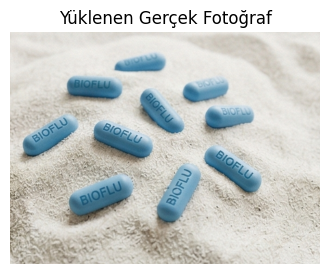


🤖 LİTERATÜR MODELLERİNİN KARARLARI:
  ──────────────────────────────────────────────────
  MobileNetV2 (Saf Derin Öğrenme) : BIOFLU
  ResNet50    (Saf Derin Öğrenme) : BIOFLU
  InceptionV3 (Saf Derin Öğrenme) : BIOFLU
  Hibrit Yaklaşım (CNN + kNN)     : BIOFLU
  Klasik Hibrit  (CNN + SVM)      : BIOFLU
  ──────────────────────────────────────────────────

🏆 YAPAY ZEKA KONSEYİ ORTAK KARARI: BIOFLU


In [ ]:
# ── HÜCRE 22: Kendi Fotoğrafını Test Et (Canlı Performans) ────────────────
from google.colab import files
print('\n📸 Sınav Vakti! Bilgisayarınızdan bir hap fotoğrafı yükleyin...')
uploaded = files.upload()

for fn in uploaded.keys():
    resim_bgr = cv2.imread(fn)
    resim_rgb = cv2.cvtColor(resim_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(resim_rgb)
    plt.title('Yüklenen Gerçek Fotoğraf')
    plt.axis('off')
    plt.show()

    # MobileNetV2 / Hibrit için 96x96
    r96      = cv2.resize(resim_bgr, (96, 96))
    r96_rgb  = cv2.cvtColor(r96, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
    r96_batch = np.expand_dims(r96_rgb, axis=0)

    # ResNet50 için 224x224 + resnet_preprocess
    r224       = cv2.resize(resim_bgr, (224, 224))
    r224_rgb   = cv2.cvtColor(r224, cv2.COLOR_BGR2RGB).astype('float32')
    r224_pre   = resnet_preprocess(np.expand_dims(r224_rgb, axis=0))
    r224_batch = r224_pre

    # InceptionV3 için 299x299 + inception_preprocess
    r299       = cv2.resize(resim_bgr, (299, 299))
    r299_rgb   = cv2.cvtColor(r299, cv2.COLOR_BGR2RGB).astype('float32')
    r299_batch = inception_preprocess(np.expand_dims(r299_rgb, axis=0))

    ozellik_feat = scaler_feat.transform(feat_model.predict(r96_batch, verbose=0))

    tl_pred_num  = np.argmax(model_tl.predict(r96_batch, verbose=0))
    tl_pred      = siniflar[tl_pred_num]

    rn_pred_num  = np.argmax(model_resnet.predict(r224_batch, verbose=0))
    rn_pred      = siniflar[rn_pred_num]

    iv3_pred_num = np.argmax(model_inception.predict(r299_batch, verbose=0))
    iv3_pred     = siniflar[iv3_pred_num]

    cnn_knn_pred = str(model_cnn_knn.predict(ozellik_feat)[0])
    cnn_svm_pred = str(model_cnn_svm.predict(ozellik_feat)[0])

    print('\n🤖 LİTERATÜR MODELLERİNİN KARARLARI:')
    print(f"  {'─'*50}")
    print(f'  MobileNetV2 (Saf Derin Öğrenme) : {tl_pred.upper()}')
    print(f'  ResNet50    (Saf Derin Öğrenme) : {rn_pred.upper()}')
    print(f'  InceptionV3 (Saf Derin Öğrenme) : {iv3_pred.upper()}')
    print(f'  Hibrit Yaklaşım (CNN + kNN)     : {cnn_knn_pred.upper()}')
    print(f'  Klasik Hibrit  (CNN + SVM)      : {cnn_svm_pred.upper()}')
    print(f"  {'─'*50}")

    tum_tahminler = [tl_pred.lower(), rn_pred.lower(), iv3_pred.lower(),
                     cnn_knn_pred.lower(), cnn_svm_pred.lower()]
    kazanan = Counter(tum_tahminler).most_common(1)[0][0]
    print(f'\n🏆 YAPAY ZEKA KONSEYİ ORTAK KARARI: {kazanan.upper()}')

In [ ]:
# ── HÜCRE 23: Modelleri Drive'a Kaydet (İsteğe Bağlı) ─────────────────────
# Bu hücreyi SADECE modelleri yeniden eğittiyseniz çalıştırın.
# Drive'daki mevcut modellerin üzerine yazar!

kayit_klasoru = '/content/drive/MyDrive/Hap_Modelleri_V3'
if not os.path.exists(kayit_klasoru):
    os.makedirs(kayit_klasoru)

print(f"📦 Modeller '{kayit_klasoru}' klasörüne kaydediliyor...")

model_tl.save(f"{kayit_klasoru}/mobilenet_v3_model.h5")
print('  ✅ MobileNetV2 kaydedildi (.h5)')

joblib.dump(model_cnn_svm, f"{kayit_klasoru}/cnn_svm_model.joblib")
joblib.dump(model_cnn_knn, f"{kayit_klasoru}/cnn_knn_model.joblib")
print('  ✅ SVM ve kNN modelleri kaydedildi (.joblib)')

joblib.dump(scaler_feat, f"{kayit_klasoru}/scaler_feat.joblib")
joblib.dump(le, f"{kayit_klasoru}/label_encoder.joblib")
print('  ✅ Scaler ve LabelEncoder kaydedildi (.joblib)')

print('\n🎉 Tüm modeller Drive\'a güvenle yedeklendi!')

📦 Modeller '/content/drive/MyDrive/Hap_Modelleri_V3' klasörüne kaydediliyor...
  ✅ MobileNetV2 kaydedildi (.h5)
  ✅ SVM ve kNN modelleri kaydedildi (.joblib)
  ✅ Scaler ve LabelEncoder kaydedildi (.joblib)

🎉 Tüm modeller Drive'a güvenle yedeklendi!
